/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



Model Comparison on Test Set:
--------------------------------------------------
TEAM:
  MSE: 2672.23
  R2:  0.496
Random Forest:
  MSE: 2952.01
  R2:  0.443
Linear Regression:
  MSE: 2900.19
  R2:  0.453
Neural Network:
  MSE: 2894.86
  R2:  0.454
--------------------------------------------------


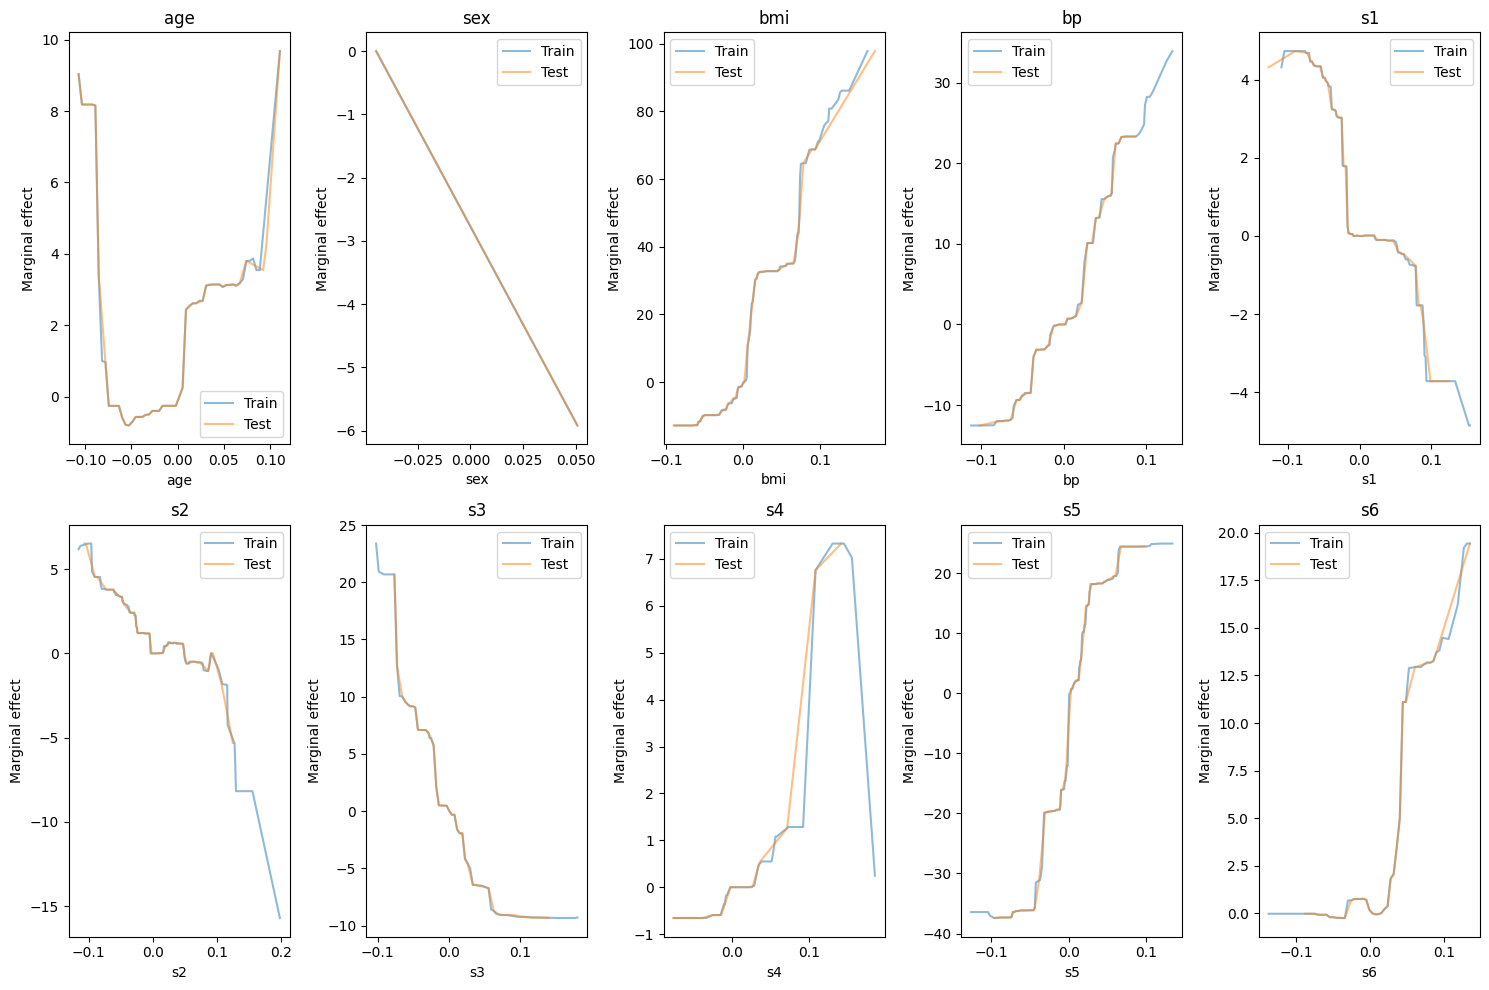


Verifying additivity property on training set:
Mean absolute difference on train set: 0.000000

Checking additivity property on test set:
Mean absolute difference on test set: 0.000000


In [8]:
"""
TEAM (Tree Ensemble Additive Model) Implementation
Copyright (c) 2024. All rights reserved.
This implementation is intellectual property of Antonio Di Cecco (the author).
The author reserves all rights for future academic publication.
Do not distribute or use without explicit permission.
Pending academic paper publication.
"""

import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

class TEAM(BaseEstimator, RegressorMixin):
    """
    Tree Ensemble Additive Model (TEAM)
    Original algorithm and implementation.
    All rights reserved for future academic publication.
    """
    def __init__(self, n_estimators=100):
        self.n_estimators = n_estimators
        self.base_estimator = GradientBoostingRegressor(max_depth=1, n_estimators=100)
        self.model = BaggingRegressor(
            estimator=self.base_estimator,
            n_estimators=self.n_estimators
        )
        self.feature_means_ = None
        self.y_mean_ = None

    def fit(self, X, y):
        self.feature_means_ = X.mean(axis=0)
        self.y_mean_ = y.mean()
        self.model.fit(X, y - self.y_mean_)
        return self

    def predict(self, X):
        return self.model.predict(X) + self.y_mean_

    def get_marginal_effect(self, i, X):
        """
        Compute the marginal effect of feature i on the prediction.
        This represents the i-th component of the additive model.

        Parameters:
        -----------
        i : int
            Index of the feature
        X : array-like
            Input data

        Returns:
        --------
        array-like
            Marginal effect of feature i, representing its contribution
            to the final prediction when all other features are at their mean values
        """
        X_mean = np.tile(self.feature_means_, (X.shape[0], 1))

        # Prediction with all features at their means
        all_mean_pred = self.model.predict(X_mean)

        # Replace i-th feature with actual values
        X_i = X_mean.copy()
        X_i[:, i] = X[:, i]

        # Prediction with only i-th feature varying
        pred_i = self.model.predict(X_i)

        return pred_i - all_mean_pred

# Load and prepare data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'TEAM': TEAM(n_estimators=100),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# Train models and collect results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

# Print comparison results
print("\nModel Comparison on Test Set:")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  MSE: {metrics['MSE']:.2f}")
    print(f"  R2:  {metrics['R2']:.3f}")
print("-" * 50)

# Plot TEAM marginal effects
team = models['TEAM']
plt.figure(figsize=(15, 10))
for i, feature_name in enumerate(feature_names):
    plt.subplot(2, 5, i+1)

    # Get marginal effect for feature i
    effect_i_train = team.get_marginal_effect(i, X_train)
    effect_i_test = team.get_marginal_effect(i, X_test)

    # Sort points by X values for both train and test
    train_idx = np.argsort(X_train[:, i])
    test_idx = np.argsort(X_test[:, i])

    # Plot sorted points
    plt.plot(X_train[train_idx, i], effect_i_train[train_idx], alpha=0.5, label='Train')
    plt.plot(X_test[test_idx, i], effect_i_test[test_idx], alpha=0.5, label='Test')
    plt.title(feature_name)
    plt.xlabel(feature_name)
    plt.ylabel('Marginal effect')
    plt.legend()

plt.tight_layout()
plt.show()

print("\nVerifying additivity property on training set:")
y_pred_train = team.predict(X_train)

# Calcola la predizione quando tutte le feature sono alla media
X_mean = np.tile(team.feature_means_, (X_train.shape[0], 1))
mean_pred = team.model.predict(X_mean)

sum_effects_train = sum(team.get_marginal_effect(i, X_train) for i in range(X.shape[1])) + mean_pred
diff_train = np.abs(y_pred_train - team.y_mean_ - sum_effects_train)
print(f"Mean absolute difference on train set: {diff_train.mean():.6f}")

# Check additivity property on test set
print("\nChecking additivity property on test set:")
y_pred_test = team.predict(X_test)

# Usa lo stesso mean_pred calcolato con le medie del training
X_mean_test = np.tile(team.feature_means_, (X_test.shape[0], 1))
mean_pred_test = team.model.predict(X_mean_test)

sum_effects_test = sum(team.get_marginal_effect(i, X_test) for i in range(X.shape[1])) + mean_pred_test
diff_test = np.abs(y_pred_test - team.y_mean_ - sum_effects_test)
print(f"Mean absolute difference on test set: {diff_test.mean():.6f}")